<a href="https://colab.research.google.com/github/clem0g/FPGA_Projects/blob/main/Spotify_Music_Recommendations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
url = 'https://drive.google.com/file/d/1rFZ-eTq6tTweS51ETdaGjvySOqFeHBPB/view?usp=sharing'
path = 'https://drive.google.com/uc?export=download&id='+url.split('/')[-2]
df = pd.read_csv(path, encoding='latin-1')

In [ ]:
df.head()


,track_name,artist(s)_name,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,...,bpm,key,mode,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook",2,2023,7,14,553,147,141381703,43,...,125,B,Major,80,89,83,31,0,8,4
1,LALA,Myke Towers,1,2023,3,23,1474,48,133716286,48,...,92,C#,Major,71,61,74,7,0,10,4
2,vampire,Olivia Rodrigo,1,2023,6,30,1397,113,140003974,94,...,138,F,Major,51,32,53,17,0,31,6
3,Cruel Summer,Taylor Swift,1,2019,8,23,7858,100,800840817,116,...,170,A,Major,55,58,72,11,0,11,15
4,WHERE SHE GOES,Bad Bunny,1,2023,5,18,3133,50,303236322,84,...,144,A,Minor,65,23,80,14,63,11,6


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            953 non-null    object
 1   artist(s)_name        953 non-null    object
 2   artist_count          953 non-null    int64 
 3   released_year         953 non-null    int64 
 4   released_month        953 non-null    int64 
 5   released_day          953 non-null    int64 
 6   in_spotify_playlists  953 non-null    int64 
 7   in_spotify_charts     953 non-null    int64 
 8   streams               953 non-null    object
 9   in_apple_playlists    953 non-null    int64 
 10  in_apple_charts       953 non-null    int64 
 11  in_deezer_playlists   953 non-null    object
 12  in_deezer_charts      953 non-null    int64 
 13  in_shazam_charts      903 non-null    object
 14  bpm                   953 non-null    int64 
 15  key                   858 non-null    ob

In [ ]:
df.isnull().sum()



,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


In [ ]:
df.drop(columns=['key'], inplace=True)


In [ ]:
df['in_shazam_charts'] = df['in_shazam_charts'].replace(',','', regex=True)


In [ ]:
df['in_shazam_charts'] = pd.to_numeric(df['in_shazam_charts'], errors='coerce')
df['in_shazam_charts'] = df['in_shazam_charts'].fillna(df['in_shazam_charts'].median()).astype(np.int64)

In [ ]:
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


In [ ]:
df.isnull().sum()

,0
track_name,0
artist(s)_name,0
artist_count,0
released_year,0
released_month,0
released_day,0
in_spotify_playlists,0
in_spotify_charts,0
streams,0
in_apple_playlists,0


In [ ]:
df = df[df["streams"].str.contains("[a-zA-Z]") == False]


In [ ]:
df['streams'] = df['streams'].replace(',','', regex=True).astype(np.int64)


In [ ]:
df = df[df["in_deezer_playlists"].str.contains("[a-zA-Z]") == False]
df['in_deezer_playlists'] = df['in_deezer_playlists'].replace(',','', regex=True).astype(np.int64)


In [ ]:
df = df.drop_duplicates(['track_name', 'artist(s)_name'])


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 948 entries, 0 to 952
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   track_name            948 non-null    object
 1   artist(s)_name        948 non-null    object
 2   artist_count          948 non-null    int64 
 3   released_year         948 non-null    int64 
 4   released_month        948 non-null    int64 
 5   released_day          948 non-null    int64 
 6   in_spotify_playlists  948 non-null    int64 
 7   in_spotify_charts     948 non-null    int64 
 8   streams               948 non-null    int64 
 9   in_apple_playlists    948 non-null    int64 
 10  in_apple_charts       948 non-null    int64 
 11  in_deezer_playlists   948 non-null    int64 
 12  in_deezer_charts      948 non-null    int64 
 13  in_shazam_charts      948 non-null    int64 
 14  bpm                   948 non-null    int64 
 15  mode                  948 non-null    object


In [ ]:
df.describe()



,artist_count,released_year,released_month,released_day,in_spotify_playlists,in_spotify_charts,streams,in_apple_playlists,in_apple_charts,in_deezer_playlists,in_deezer_charts,in_shazam_charts,bpm,danceability_%,valence_%,energy_%,acousticness_%,instrumentalness_%,liveness_%,speechiness_%
count,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,9.480000e+02,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000,948.000000
mean,1.559072,2018.274262,6.037975,13.929325,5205.736287,12.072785,5.140179e+08,67.709916,52.053797,386.427215,2.658228,56.830169,122.473629,66.966245,51.376582,64.261603,27.159283,1.568565,18.184599,10.154008
std,0.894481,11.032289,3.567220,9.194844,7914.809436,19.608092,5.679277e+08,86.346061,50.674649,1133.346458,6.019615,157.496879,28.047409,14.644716,23.519759,16.585738,26.025796,8.410065,13.706098,9.933332
min,1.000000,1930.000000,1.000000,1.000000,31.000000,0.000000,2.762000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,65.000000,23.000000,4.000000,9.000000,0.000000,0.000000,3.000000,2.000000
25%,1.000000,2020.000000,3.000000,6.000000,874.500000,0.000000,1.411439e+08,13.000000,7.000000,13.000000,0.000000,0.000000,99.000000,57.000000,32.000000,53.000000,6.000000,0.000000,10.000000,4.000000
50%,1.000000,2022.000000,6.000000,13.000000,2216.500000,3.000000,2.876903e+08,34.000000,38.500000,44.000000,0.000000,2.000000,120.500000,69.000000,51.000000,66.000000,18.000000,0.000000,12.000000,6.000000
75%,2.000000,2022.000000,9.000000,22.000000,5503.750000,16.000000,6.729425e+08,87.250000,87.000000,164.000000,2.000000,33.250000,140.000000,78.000000,70.000000,77.000000,43.000000,0.000000,23.250000,11.000000
max,8.000000,2023.000000,12.000000,31.000000,52898.000000,147.000000,3.703895e+09,672.000000,275.000000,12367.000000,58.000000,1451.000000,206.000000,96.000000,97.000000,97.000000,97.000000,91.000000,97.000000,64.000000


In [ ]:
df.describe(include='object')



,track_name,artist(s)_name,mode
count,948,948,948
unique,942,644,2
top,Die For You,Taylor Swift,Major
freq,2,34,546


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


Text(0.5, 1.0, 'Artist Occurance in top 1000 Songs of 2023')

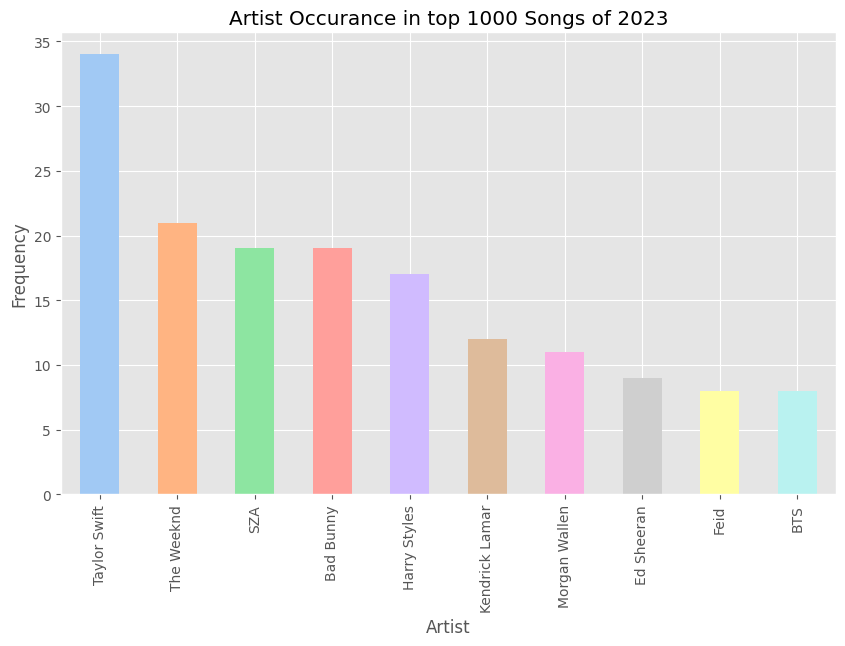

In [ ]:
artist_counts = df['artist(s)_name'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,6))
plt.style.use(['ggplot'])
c = sns.color_palette("pastel")
artist_counts.head(10).plot.bar(color=c)
plt.xlabel("Artist")
plt.ylabel("Frequency")
plt.title('Artist Occurance in top 1000 Songs of 2023')


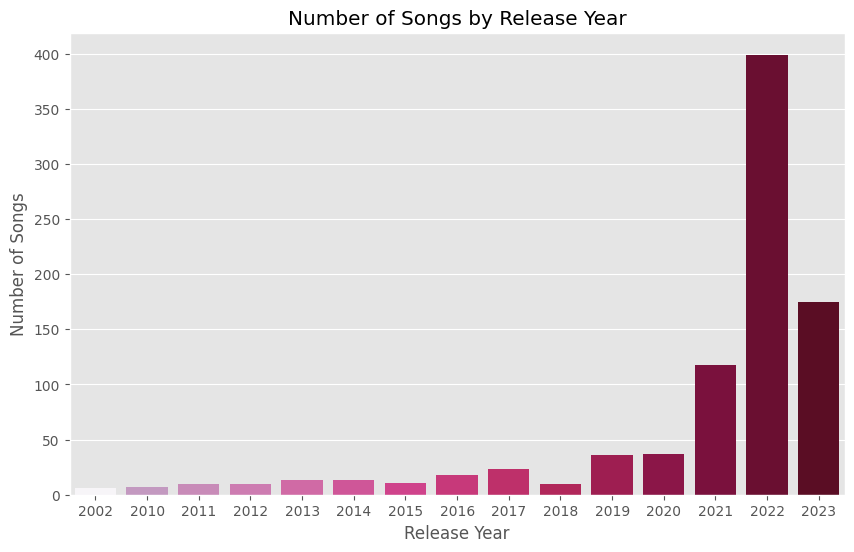

In [ ]:
songs_by_year = df['released_year'].value_counts().reset_index()
songs_by_year.columns = ['released_year', 'count']

plt.figure(figsize=(10, 6))
sns.barplot(x='released_year', y='count', data=songs_by_year.head(15), palette='PuRd',hue='released_year', legend=False)
plt.title('Number of Songs by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Songs')
plt.show()


Text(0.5, 1.0, 'Song BPM Distribution')

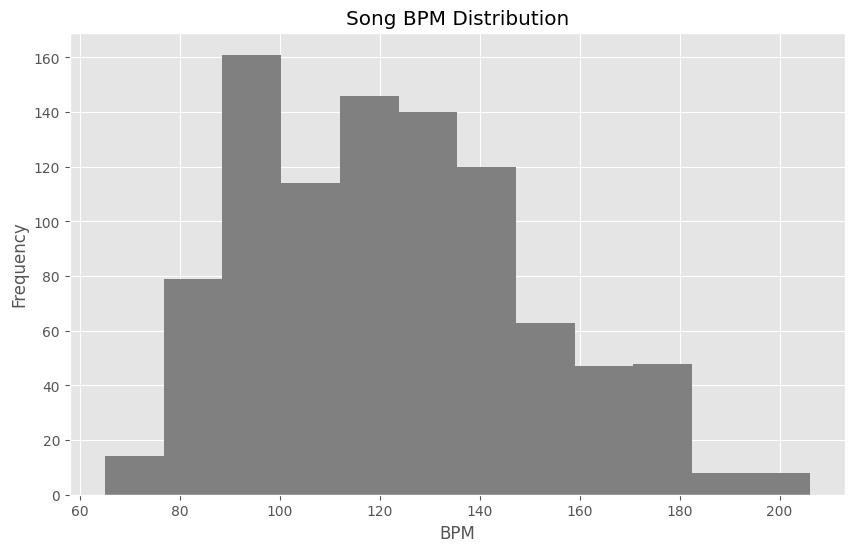

In [ ]:
plt.figure(figsize=(10, 6))
df['bpm'].hist(color='gray',bins=12)
plt.xlabel("BPM")
plt.ylabel("Frequency")
plt.title('Song BPM Distribution')


<Figure size 900x900 with 0 Axes>

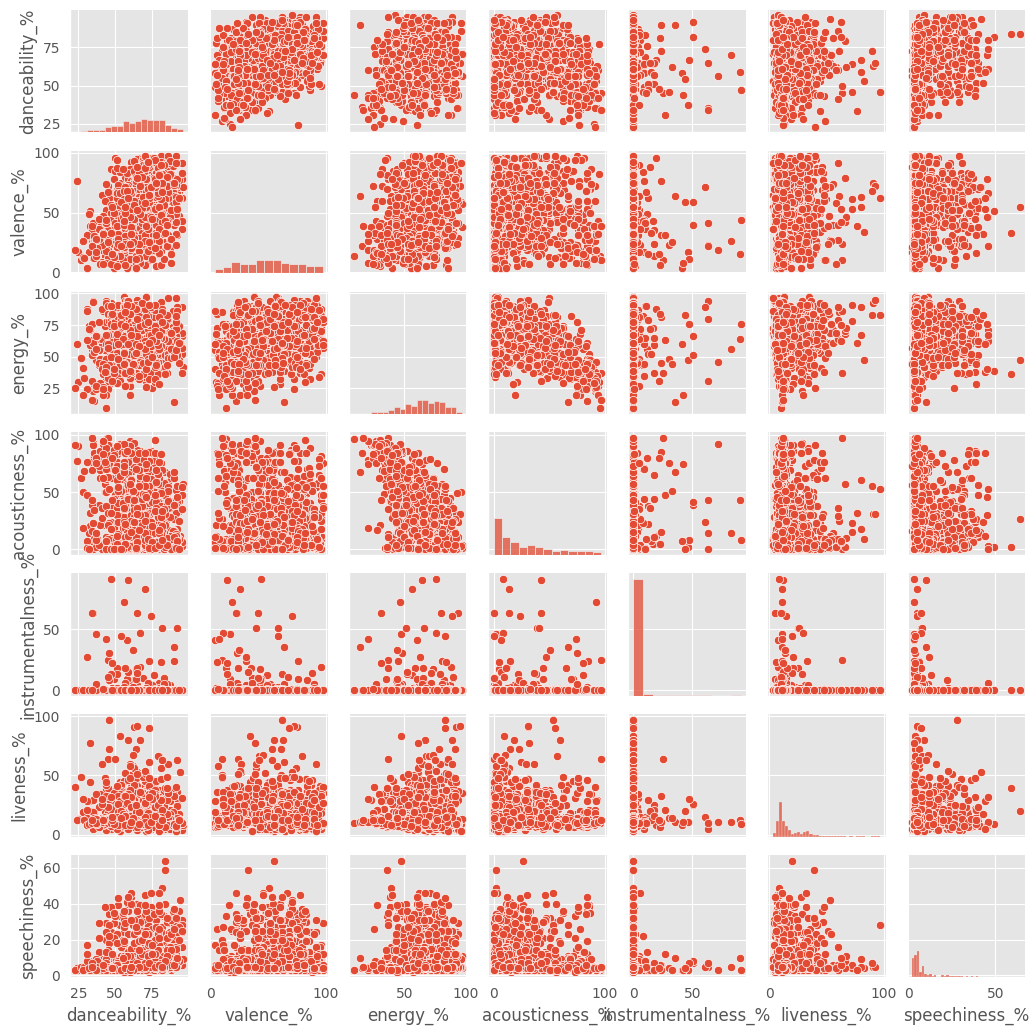

In [ ]:
df_attribute = df[['danceability_%','valence_%','energy_%','acousticness_%','instrumentalness_%','liveness_%','speechiness_%']]

plt.figure(figsize=(9, 9))
sns.set_style("white")
plt.style.use(['ggplot'])
sns.pairplot(df_attribute, height=1.5)


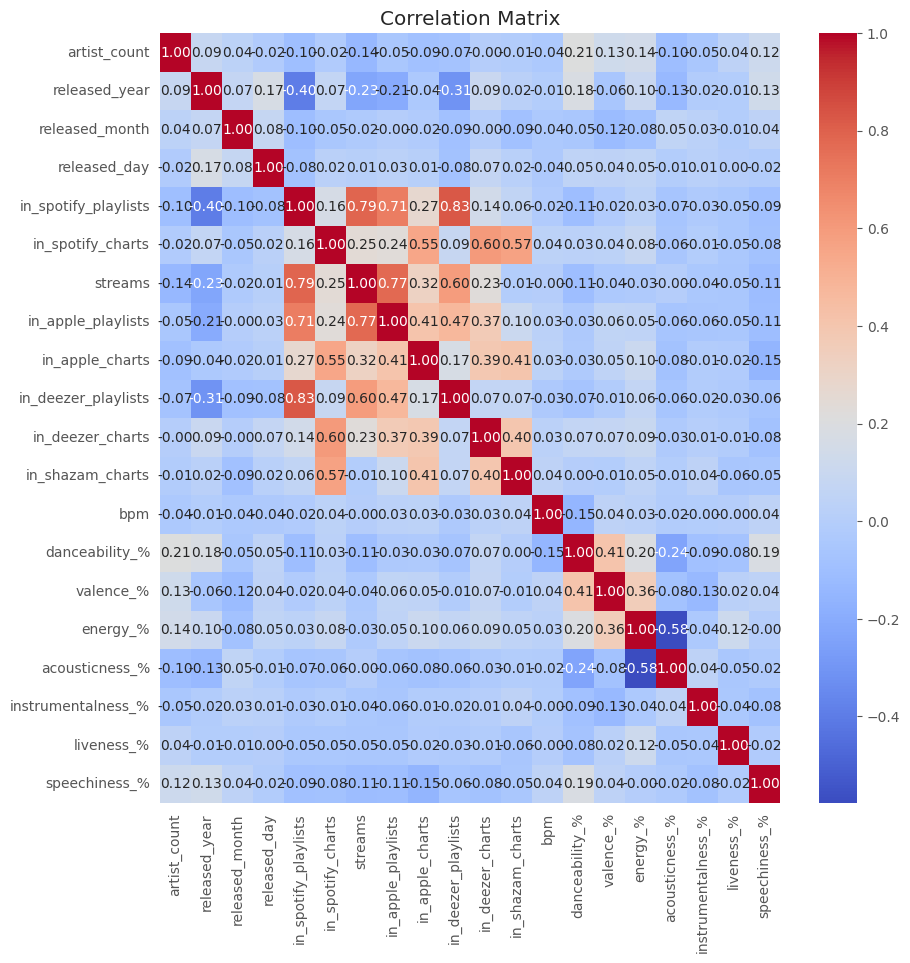

In [ ]:
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the correlation matrix
correlation_matrix = numeric_df.corr()

# Plot the correlation matrix using Seaborn
plt.figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


In [ ]:
dummies = pd.get_dummies(df['mode'],prefix="mode")

df_encode = pd.concat([df, dummies], axis=1)

#dummies = pd.get_dummies(df['released_month'],prefix="released_month")

#df_encode = pd.concat([df_encode, dummies], axis=1)

df_encode.drop(columns=["released_month","mode","artist(s)_name","track_name","released_day"], inplace=True)


In [ ]:
df_encode.info()


<class 'pandas.core.frame.DataFrame'>
Index: 948 entries, 0 to 952
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   artist_count          948 non-null    int64
 1   released_year         948 non-null    int64
 2   in_spotify_playlists  948 non-null    int64
 3   in_spotify_charts     948 non-null    int64
 4   streams               948 non-null    int64
 5   in_apple_playlists    948 non-null    int64
 6   in_apple_charts       948 non-null    int64
 7   in_deezer_playlists   948 non-null    int64
 8   in_deezer_charts      948 non-null    int64
 9   in_shazam_charts      948 non-null    int64
 10  bpm                   948 non-null    int64
 11  danceability_%        948 non-null    int64
 12  valence_%             948 non-null    int64
 13  energy_%              948 non-null    int64
 14  acousticness_%        948 non-null    int64
 15  instrumentalness_%    948 non-null    int64
 16  liveness_%   

In [ ]:
#@title Create Clusters Data


import numpy as np
from sklearn.datasets import make_blobs

np.random.seed(31)

# Parameters
num_samples = 500  # Total number of data points
num_clusters = 5   # Number of clusters
cluster_std = 0.9  # Standard deviation of clusters

# Generate random clusters
X, y = make_blobs(n_samples=num_samples, centers=num_clusters, cluster_std=cluster_std)

# Create 2D numpy array with random data points
data = np.column_stack((X[:, 0], X[:, 1]))


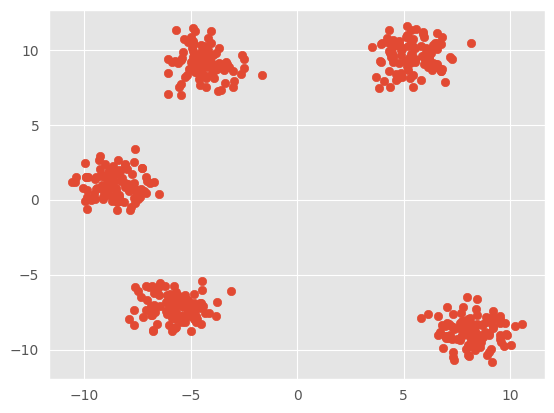

In [ ]:
plt.scatter(data[:,0],X[:,1])


In [ ]:
from sklearn.metrics import pairwise_distances_argmin

def find_clusters(X, n_clusters, rseed=100): # Function
  # Step 1. Randomly choose cluster centers
  epochs=0
  rng = np.random.RandomState(rseed)
  i = rng.permutation(X.shape[0])[:n_clusters]
  centers = X[i]

  while True:
    epochs += 1
    #2a. E-step: Assign labels based on closest center
    labels = pairwise_distances_argmin(X,centers)
    #2b. M-step: Find new centers from means of points in clusters
    new_centers = np.array([X[labels == i].mean(0)
                            for i in range(n_clusters)])
    #2c. Check for Convergence to end
    if np.all(centers == new_centers):
      print("k-means converged at " + str(epochs) + " steps")
      break
    else:
      centers = new_centers

  return centers, labels


k-means converged at 11 steps


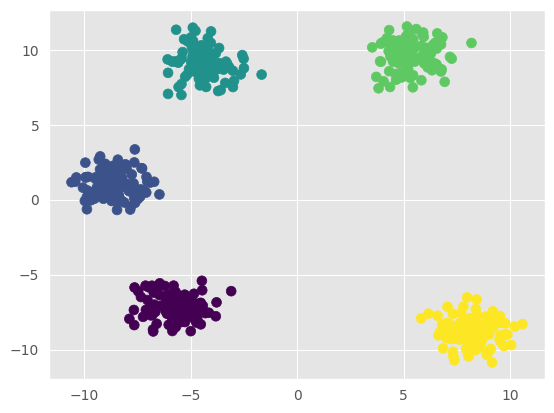

In [ ]:
centers, labels = find_clusters(data, 5, 68) #Hyperparameters: number of clusters, random seed

plt.scatter(data[:,0],data[:,1], c=labels, s=50, cmap='viridis')


k-means converged at 5 steps


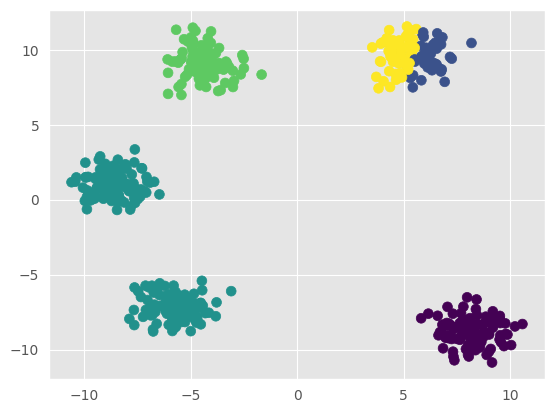

In [ ]:
centers, labels = find_clusters(data, 5, 32) # Changed the random state
plt.scatter(data[:,0],data[:,1], c=labels, s=50, cmap='viridis')


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_encode_scaled = scaler.fit_transform(df_encode)


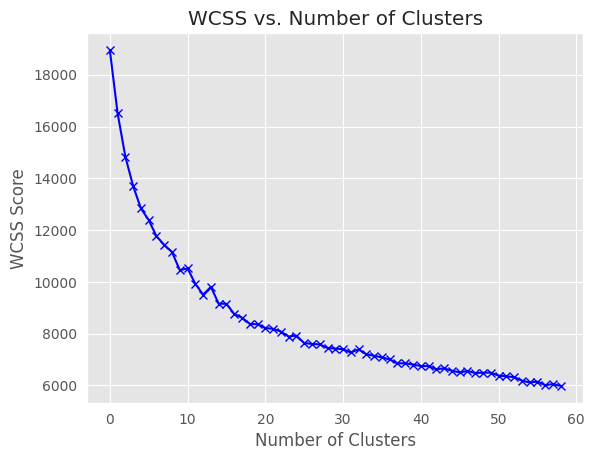

In [ ]:
import matplotlib.pyplot as plt

score_1 = []
range_values = range(1, 60)
for i in range_values:
    kmeans = KMeans(n_clusters = i, n_init = "auto")
    kmeans.fit(df_encode_scaled)
    score_1.append(kmeans.inertia_)

plt.plot(score_1, 'bx-')
plt.title('WCSS vs. Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Score')
plt.show()


In [ ]:
kmeans = KMeans(n_clusters = 16, init = 'k-means++', max_iter = 400, n_init = 10, random_state = 9)
labels = kmeans.fit_predict(df_encode_scaled)


In [ ]:
df_cluster = pd.concat([df, pd.DataFrame({'cluster': labels})], axis = 1)


In [ ]:
df_cluster.dropna(axis=0,inplace=True)
df_cluster.shape


(943, 24)

In [ ]:
# User inputs 'vampire' by 'Olivia Rodrigo'
condition = (df_cluster['track_name']=='vampire') & (df_cluster['artist(s)_name']=='Olivia Rodrigo')
desired_cluster = df_cluster[condition].cluster.to_numpy()[0]

# Output songs in the same cluster
df_cluster[df_cluster['cluster'] == desired_cluster][['track_name','artist(s)_name']]


,track_name,artist(s)_name
0,Seven (feat. Latto) (Explicit Ver.),"Latto, Jung Kook"
2,vampire,Olivia Rodrigo
3,Cruel Summer,Taylor Swift
5,Sprinter,"Dave, Central Cee"
8,fukumean,Gunna
12,Flowers,Miley Cyrus
13,Daylight,David Kushner
17,What Was I Made For? [From The Motion Picture ...,Billie Eilish
24,Popular (with Playboi Carti & Madonna) - The I...,"The Weeknd, Madonna, Playboi Carti"
44,Barbie World (with Aqua) [From Barbie The Album],"Nicki Minaj, Aqua, Ice Spice"
